In [41]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [2]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [44]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "local_MDwarfFlares_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




[INFO] Loaded metric module: local_MDwarfFlares_metric
[INFO] Loaded shared_utils module


In [29]:
#cristina's version
stars_per_cubic_parsec = 0.003 
stars_per_cubic_megaparsec = stars_per_cubic_parsec*((10**6)**3) #cubic pc/mpc
flares_per_star_per_year = 365
flares_per_cubic_mpc_per_year_c = stars_per_cubic_megaparsec*flares_per_star_per_year

In [30]:
#riley's version
stars_per_cubic_parsec = 0.06
stars_per_cubic_megaparsec = stars_per_cubic_parsec*((10**6)**3) #cubic pc/mpc
flares_per_star_per_year = 365
flares_per_cubic_mpc_per_year_r = stars_per_cubic_megaparsec*flares_per_star_per_year

In [18]:
#reversing from numbers
rate_per_year = 10**11
d_min, d_max = d_min, d_max = 0.0000013, .03
V = ((4/3)*np.pi*(d_max**3 - d_min**3))
#except only within 30 degrees
#how much of a sphere is plus or minus 30 degrees i wonder
#i think it's actually just a third
new_rate_density = 3*(rate_per_year / V)*(65130/44516)

In [19]:
#metric configurations


#use this to add text to the filename
#if you're testing template or population variables other than the below variables
testname=None  

#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria
testname_metric_only=None 

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = True 
generate_new_pop = True
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = new_rate_density / 10**6
# rate_density = 76*10**9/((4/3)*np.pi*(.03**3-0.0000013**3)) /1000000
#dividing by 10**9 so that we can actually use these numbers

#the milky way contains 100–400 billion stars
#76% of main sequence stars are m dwarfs
#i dont know how many non-main-sequence stars there are so...
#let's say there are 100 billion main sequence stars
#so 76 billion m dwarfs
#rate density calculation: 76*10*9 /((4/3)*np.pi*(.03**3-0.0000013**3))
#....that's the number of m dwarfs. it's supposed to be per year but it's not right now
#how many flares does a star have per year?

# apply None for non-use case 
z_min, z_max = None, None #.00226, .3
d_min, d_max = 0.0000013, .03 # #proxima cen is an m-dwarf apparently at 1.3 pc
#the milky way is 30 kpc across and the sun is 8kpc from the center
#let's just use 30 kpc because we don't have a way to weight it right now


#other
gal_lat_cut = 30 #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

use_kcorrect=False
k_correct_type = None
k_correct_arg = None

num_lightcurves=1000

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
# cadences = ['four_roll_v4.3.1_10yrs'] #'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
cadences = ['four_roll_v5.0.0_10yrs', 'baseline_v5.0.0_10yrs','noroll_v3.6_10yrs','baseline_v3.6_10yrs']

ignore_triples = False #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="MDwarfFlares", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

MDwarfFlares_den_3880912272.582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None


In [30]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912272.582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl
Loaded flare templates from /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912272.582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl


In [145]:
importlib.reload(metric)
importlib.reload(shared_utils)

<module 'shared_utils' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/shared_utils.py'>

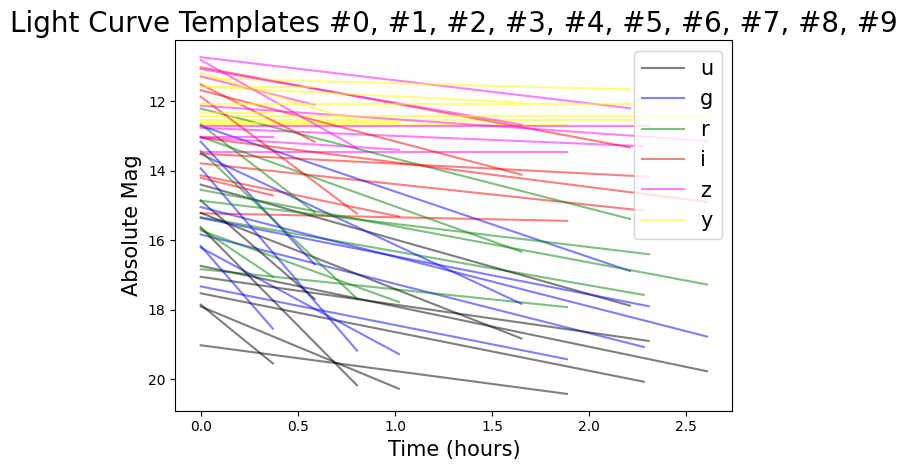

In [31]:
#plot light curves from pkl file if desired
# ylim = (20,17)
ylim=None
use_log_time = False
plot_overlap = True
plot_hours = True
shared_utils.plot_template_lcs(templates_file, num=10, use_log_time = use_log_time,plot_overlap=plot_overlap,ylim=ylim, plot_hours=plot_hours)

[INFO] Generating population and saving to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912272.582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
Simulated 4389361 events using rate_density = 3.9e+09
Len ra before masking:  4389361
b:  [ 31.42221553 -69.77132472 -42.30667511 ... -44.01084228 -26.88453721
 -63.06428065]
len mask, num true in mask:  4389361 2194080
len ra after masking:  2194080


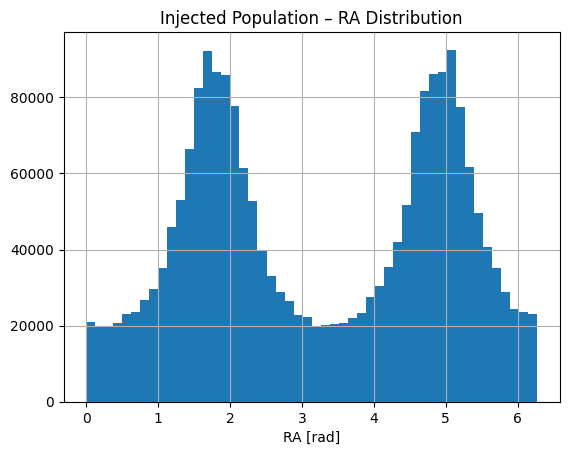

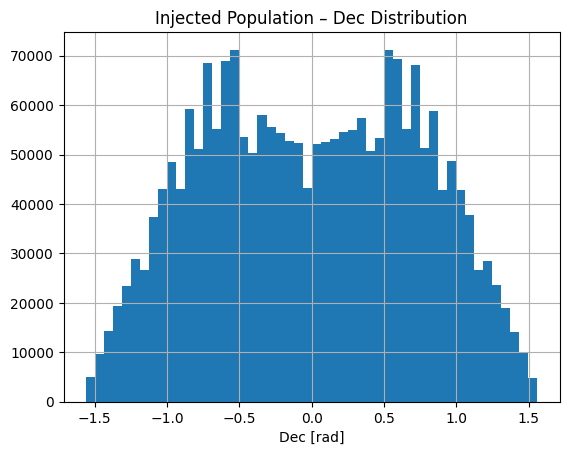

initial peak times:  [ 509.87290035 2766.04221779 1475.64054229 ... 1796.9015707  1096.47544948
  843.66557521]
gal_lat_cut is none


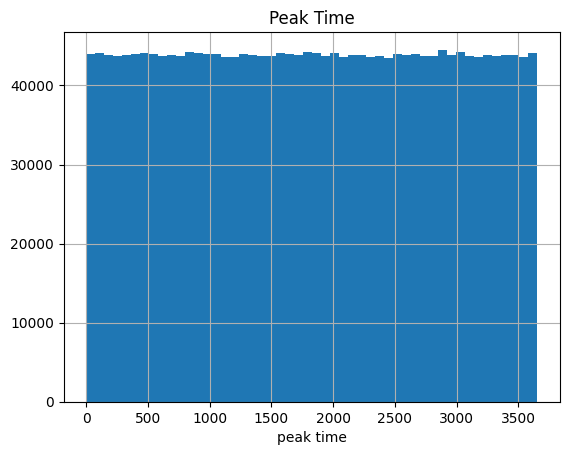

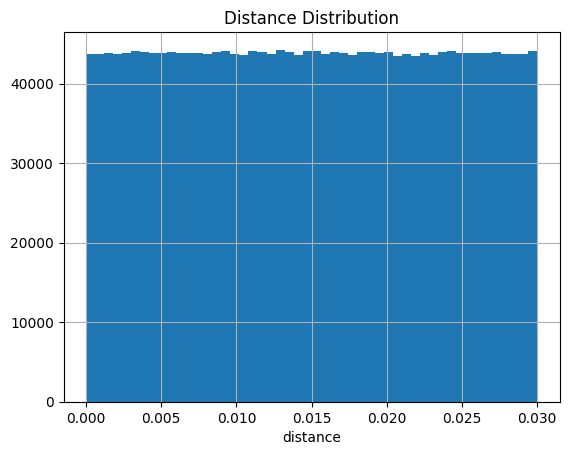

[DEBUG] coords.dec[:5]: [  7.18075578 -45.78396716 -23.31795707  36.42357364 -27.95318688] deg
[DEBUG] coords.dec.unit: deg


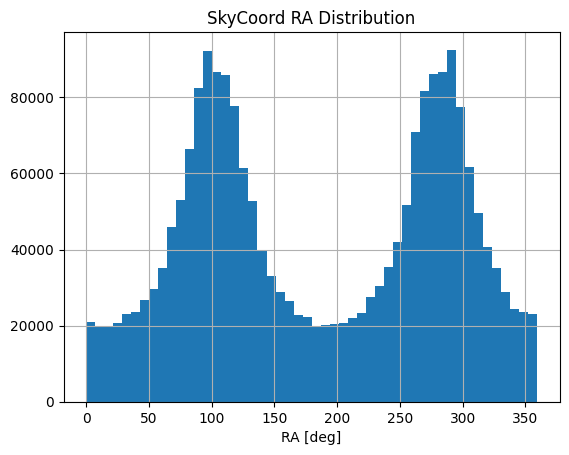

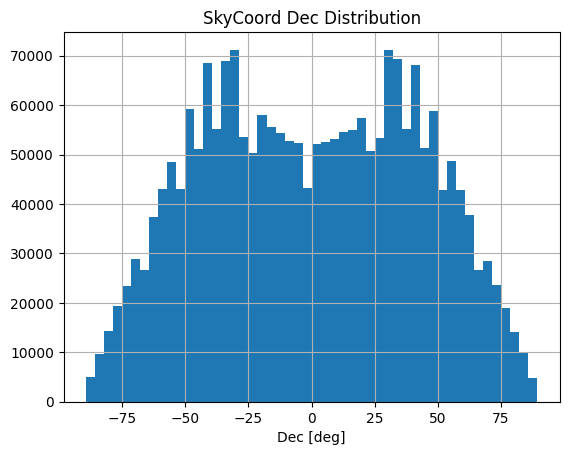

[INFO] Saved atomically to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_3880912272.582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (2194080,)


In [32]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=num_lightcurves, #technically should read this from the file
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


## All 10 years

In [39]:
importlib.reload(shared_utils)
importlib.reload(metric)

<module 'local_MDwarfFlares_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/MDwarfFlare/local_MDwarfFlares_metric.py'>

In [40]:
#run detection metric
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=None,
                                 k_correct_arg=None,
                                 use_extinction=use_extinction)


--- Running four_roll_v5.0.0_10yrs ---
band:  z
band:  z
band:  y
band:  y
band:  y
band:  z
band:  i
band:  i
band:  z
band:  z
band:  i
band:  z
band:  i
band:  z
band:  i
band:  y
band:  y
band:  y
band:  y
band:  y
band:  z
band:  z
band:  g
mag_q:  18.57038030873538
mag:  21.432913149188163
detected
band:  i
band:  i
band:  i
band:  y
band:  z
band:  y
band:  z
band:  y
band:  z
band:  i
band:  r
mag_q:  16.934457583077872
mag:  22.908312493152188
detected
band:  z
band:  z
band:  y
band:  y
band:  i
band:  z
band:  y
band:  y
band:  i
band:  z
band:  z
band:  y
band:  z
band:  r
mag_q:  15.904201910160555
mag:  23.521007648469364
detected
band:  z
band:  i
band:  z
band:  i
band:  z
band:  z
band:  y
band:  z
band:  z
band:  z
band:  u
mag_q:  19.438872289685676
mag:  22.970809852480702
detected
band:  r
mag_q:  16.686027524138602
mag:  22.21174552338243
detected
band:  u
mag_q:  19.092551182863442
mag:  22.940831170369158
detected
band:  g
mag_q:  17.000918759723113
mag:  14.71

KeyboardInterrupt: 

In [8]:

#choose what to run in run_multi_metrics
# we can remove historical if we want
# ,'silver','gold'
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=[ 'detect'], use_extinction=use_extinction)#, use_kcorrect=use_kcorrect, k_correct_type=None, k_correct_arg=None)


# Apply consistent diagnostics knobs
for m in multi_metrics:
    m.diag_store = False
    m.diag_sample_rate = 0.01
    m.diag_per_event_cap = 30
    m.diag_min_snr = 3
    m.diag_max_mag = None



In [ ]:
summary_df_bigger = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=False, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v5.0.0_10yrs ---
(1,)


In [ ]:
summary_df_bigger

In [319]:



cols = ["sid",
        "injected_peak_ebv_mag_r",
        "injected_peak_ebv_mag_r_cadence",
        "eval_peak_mag"]
print(df_obs[cols].head())

print("Residuals vs cadence-aware (should ~0):",
      np.nanmedian(df_obs["eval_peak_mag"] - df_obs["injected_peak_ebv_mag_r_cadence"]))

print("Cadence penalty (cadence − global):",
      np.nanmedian(df_obs["injected_peak_ebv_mag_r_cadence"] - df_obs["injected_peak_ebv_mag_r"]))


   sid  injected_peak_ebv_mag_r  injected_peak_ebv_mag_r_cadence  \
0    0                33.283124                              NaN   
1    1                30.145389                              NaN   
2    2                34.265142                              NaN   
3    4                27.798796                              NaN   
4    5                34.182891                              NaN   

   eval_peak_mag  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
Residuals vs cadence-aware (should ~0): 0.0
Cadence penalty (cadence − global): 0.48632856095298393



--- Running four_roll_v5.0.0_10yrs ---
(1,)
                                      Sum                     run  \
four_roll_v5.0.0_10yrs_Detect_Metric  7.0  four_roll_v5.0.0_10yrs   

                                      n_events_full_sky  
four_roll_v5.0.0_10yrs_Detect_Metric             219137  


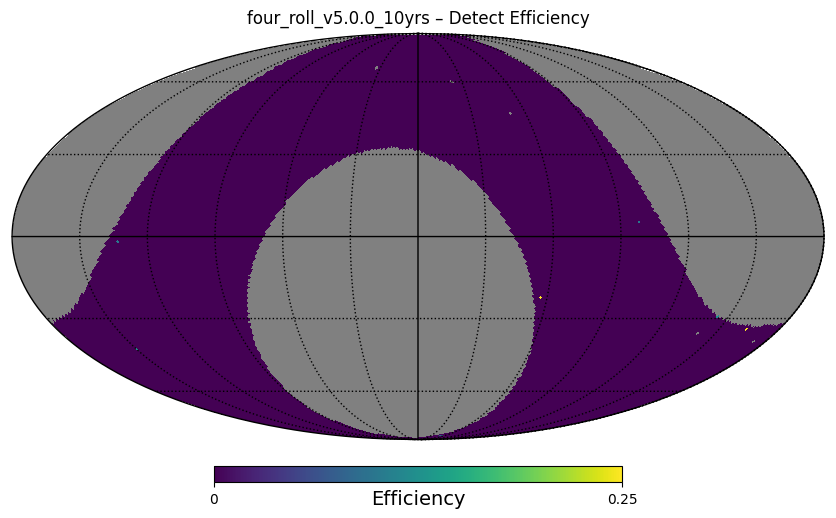

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v5.0.0_10yrs ---
(1,)


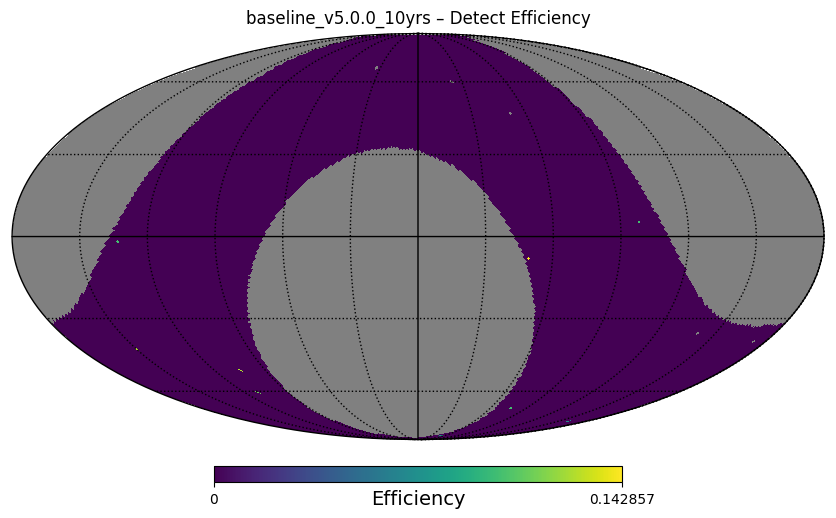

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
(1,)


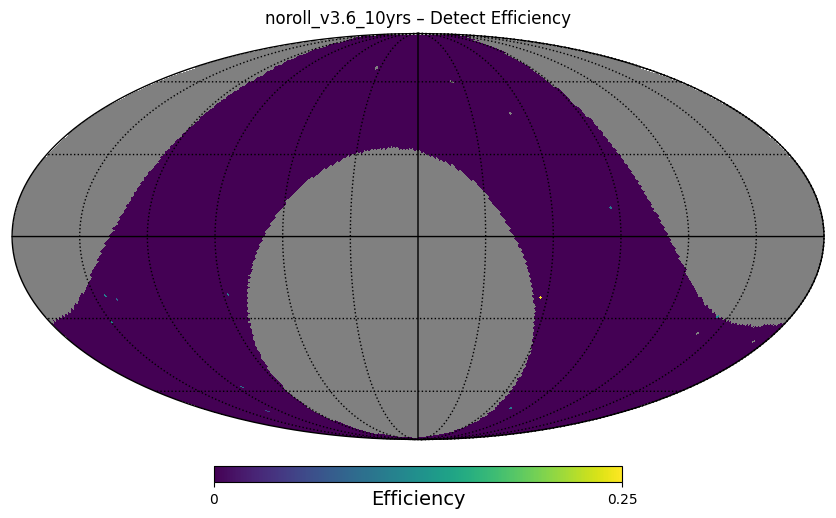

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs

--- Running baseline_v3.6_10yrs ---
(1,)


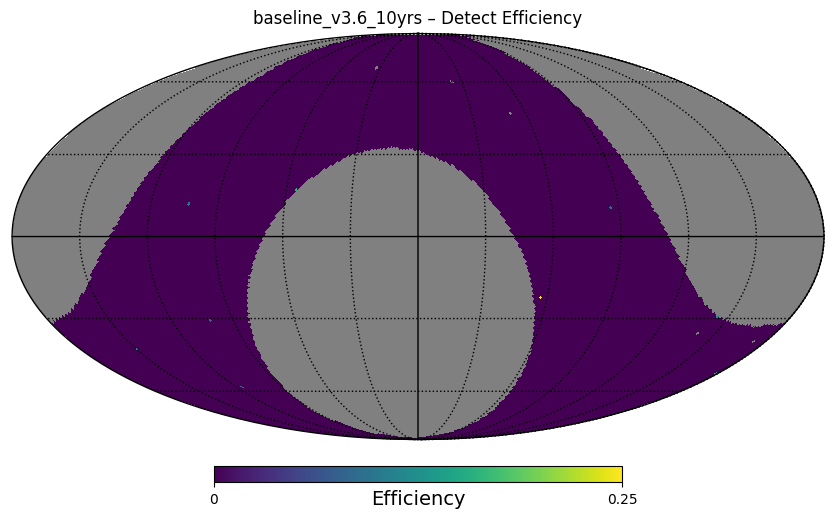

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v5.0.0_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_noroll_v3.6_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_baseline_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_388091227.2582138_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [25]:
summary_df = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [26]:
summary_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,7.0,four_roll_v5.0.0_10yrs,219137
baseline_v5.0.0_10yrs_Detect_Metric,9.0,baseline_v5.0.0_10yrs,219137
noroll_v3.6_10yrs_Detect_Metric,10.0,noroll_v3.6_10yrs,219137
baseline_v3.6_10yrs_Detect_Metric,9.0,baseline_v3.6_10yrs,219137



--- Running four_roll_v4.3.1_10yrs ---
(3,)
[<local_MDwarfFlares_metric.Detect_Metric object at 0x721ebc650>, <local_MDwarfFlares_metric.MDwarfFlareSilverMetric object at 0x32b9d9490>, <local_MDwarfFlares_metric.MDwarfFlareGoldMetric object at 0xf82b85590>]
                                      Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  7.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric             380787  


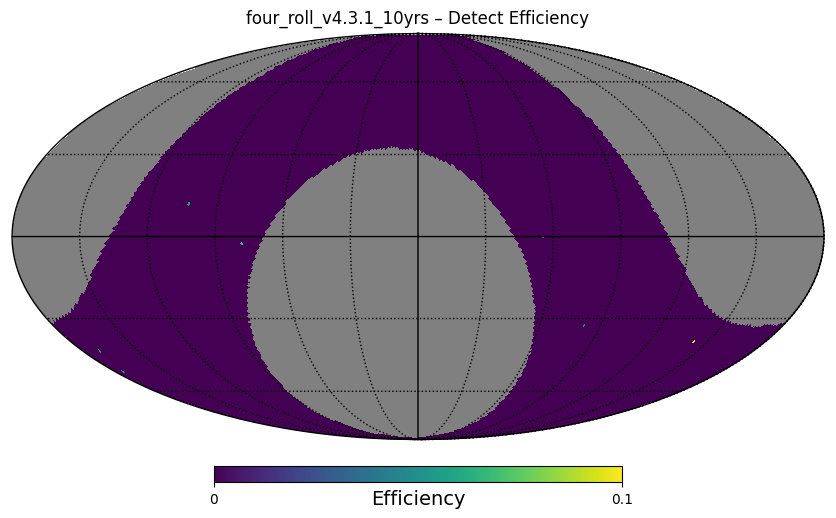

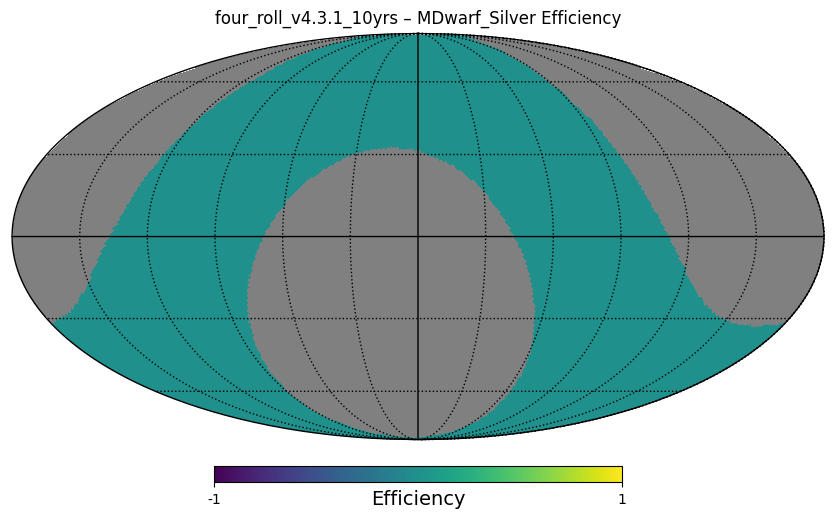

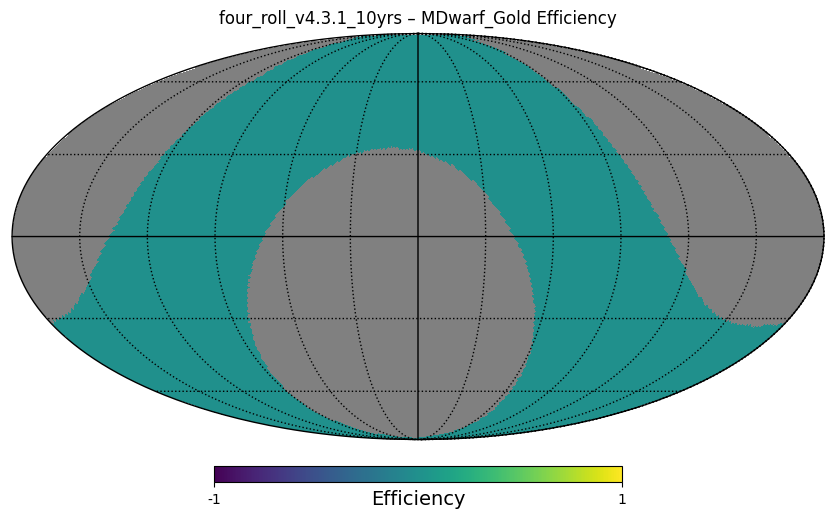

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [321]:
summary_df_2 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v4.3.1_10yrs ---
(3,)
[<local_MDwarfFlares_metric.Detect_Metric object at 0x721ebc650>, <local_MDwarfFlares_metric.MDwarfFlareSilverMetric object at 0x32b9d9490>, <local_MDwarfFlares_metric.MDwarfFlareGoldMetric object at 0xf82b85590>]
                                      Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  7.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric             380787  


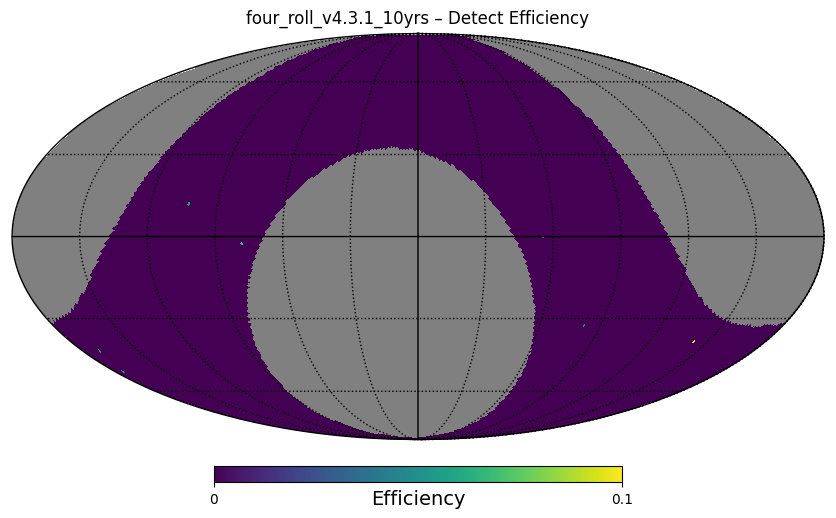

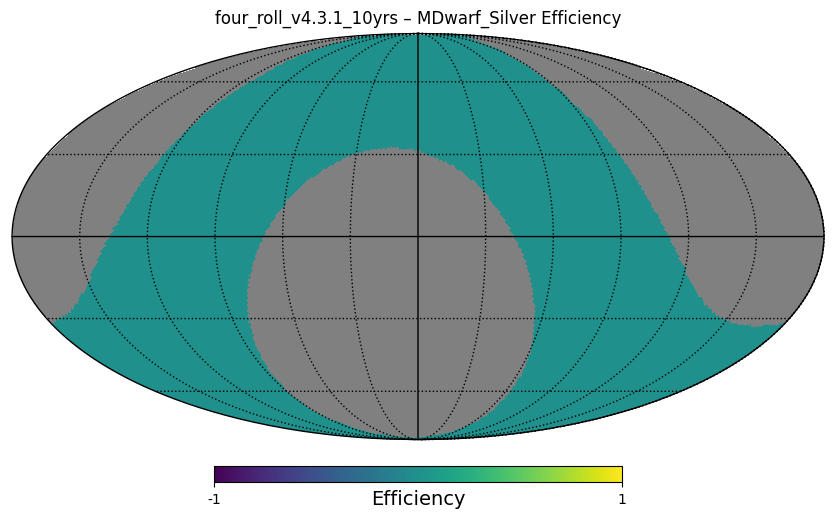

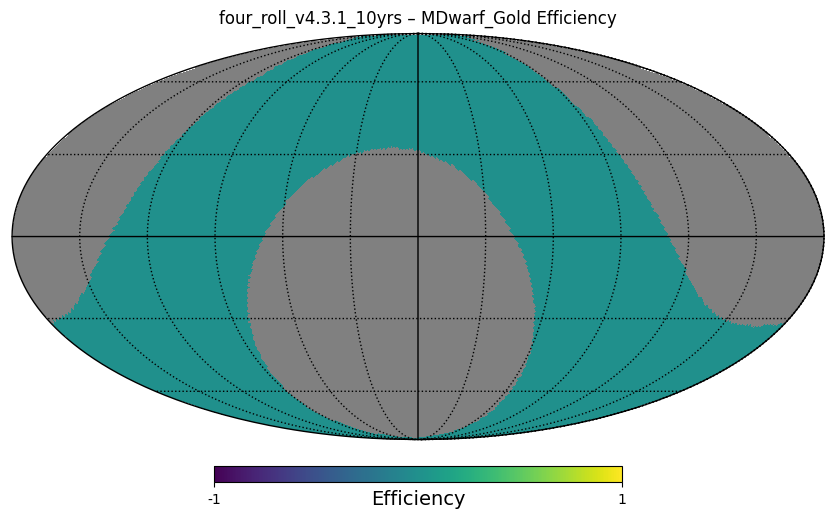

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_ext_True_kcor_None_None_None_multi_summary.csv


In [322]:
summary_df_1 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [323]:
summary_df_1

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,7.0,four_roll_v4.3.1_10yrs,380787
four_roll_v4.3.1_10yrs_MDwarfFlareSilverMetric,0.0,four_roll_v4.3.1_10yrs,380787
four_roll_v4.3.1_10yrs_MDwarfFlareGoldMetric,0.0,four_roll_v4.3.1_10yrs,380787


In [325]:
import pickle
with open(pop_file, 'rb') as f:
    sp = pickle.load(f)
missing = [f'peak_app_mag_ebv_{f}' for f in ('u','g','r','i','z','y') if f'peak_app_mag_ebv_{f}' not in sp]
print("Missing peak columns:", missing or "None — all present")


Missing peak columns: None — all present


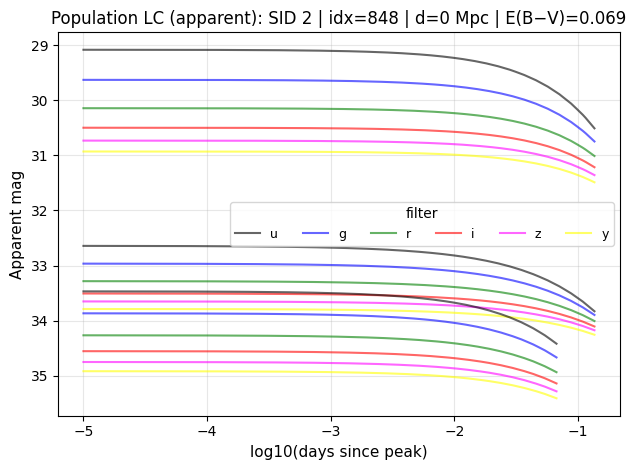

In [327]:
shared_utils.plot_population_lcs(
    pop_file=pop_file,
    lc_model=shared_lc_model,   # or pass templates_file=templates_file
    fast_peaks=False,
    use_kcorrect=use_kcorrect,
    k_correct_type=k_correct_type,
    k_correct_arg=k_correct_arg,
    num=3,
    days_before=0.0,            # see note below
    days_after=100.0,
    use_log_time=True,
    overlap=True
)


In [23]:
# Quiescent magnitude ranges (for amplitude reference)
filts = ["u", "g", "r", "i", "z", "y"]
QUIESCENT_MAG_RANGES = { 
    'u': (17.5, 20.5),
    'g': (16.5, 19.5),
    'r': (15.0, 18.0),
    'i': (13.0, 15.5),
    'z': (12.0, 13.5),
    'y': (11.5, 12.7)
}
rng = np.random.default_rng(42)

#delta mag at peak #shar todo
delta_mag = rng.uniform(0,3) #ideally we want the distribution peaked around .7 instead of uniform
qmin_g, qmax_g = QUIESCENT_MAG_RANGES['g']
quiescent_g = rng.uniform(qmin_g, qmax_g) 
# Peak brightness
peak_mag = quiescent_g - delta_mag
mag_fade = np.array([peak_mag, quiescent_g])
#okay a way to approximate the quiescent distribution - we'll scale it
quiescent_g_scale = (quiescent_g - qmin_g) / (qmax_g - qmin_g)

for f in filts:
    qmin, qmax = QUIESCENT_MAG_RANGES[f]
    mag_f_quiescent = (qmax-qmin) * quiescent_g_scale + qmin
    print(quiescent_g_scale, f, mag_f_quiescent)

0.43887843975205243 u 18.816635319256157
0.43887843975205243 g 17.816635319256157
0.43887843975205243 r 16.316635319256157
0.43887843975205243 i 14.097196099380131
0.43887843975205243 z 12.658317659628079
0.43887843975205243 y 12.026654127702463


In [47]:
total_duration = rng.uniform(np.log(60), np.log(11000))
total_duration = np.exp(total_duration) / (60*60*24)  # convert to days

In [48]:
total_duration*(60*60*24)

np.float64(3168.0655692839964)

In [49]:
a, b = 2, 6.5  # Peaks around 0.233 on [0,1], or 0.7 on [0,3]
delta_mag = rng.beta(a, b) * 3

(array([15., 18., 21., 26.,  6.,  4.,  5.,  1.,  3.,  1.]),
 array([0.06913168, 0.28406481, 0.49899794, 0.71393106, 0.92886419,
        1.14379732, 1.35873045, 1.57366357, 1.7885967 , 2.00352983,
        2.21846296]),
 <BarContainer object of 10 artists>)

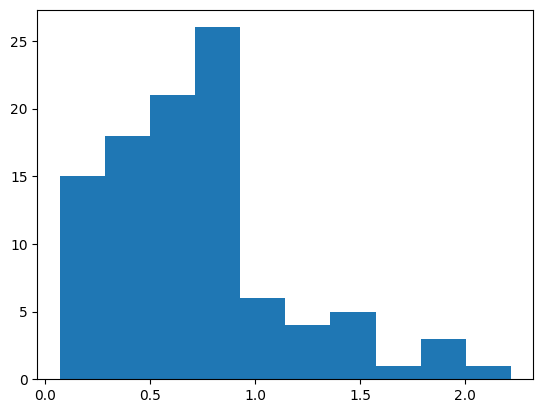

In [51]:
a_bunch = [rng.beta(a, b) * 3 for i in range(100)]
plt.hist(a_bunch)

(array([ 1.,  1.,  0.,  6., 11., 15., 36., 18.,  9.,  3.]),
 array([-1.12420641, -0.82963976, -0.5350731 , -0.24050644,  0.05406021,
         0.34862687,  0.64319353,  0.93776019,  1.23232684,  1.5268935 ,
         1.82146016]),
 <BarContainer object of 10 artists>)

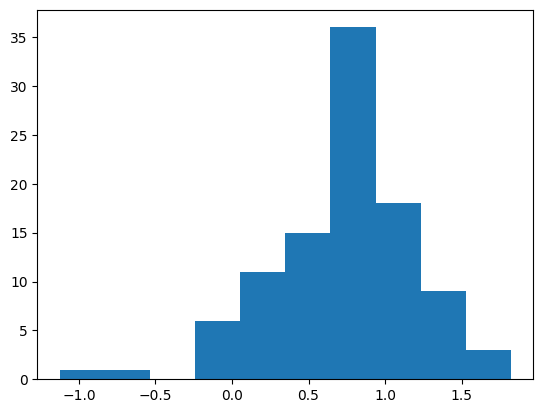

In [56]:

a_bunch = [rng.normal(0.7, 0.5) for i in range(100)]
plt.hist(a_bunch)


(array([13., 11., 17., 19., 17.,  7., 13.,  1.,  0.,  2.]),
 array([0.        , 0.21046054, 0.42092109, 0.63138163, 0.84184217,
        1.05230272, 1.26276326, 1.4732238 , 1.68368434, 1.89414489,
        2.10460543]),
 <BarContainer object of 10 artists>)

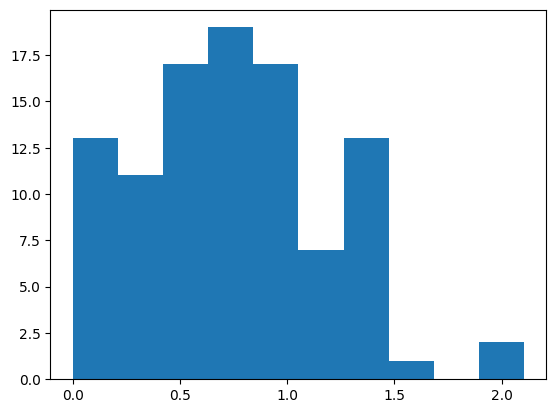

In [57]:
# delta_mag = rng.normal(0.7, 0.4)  # mean=0.7, std=0.4
# delta_mag = np.clip(delta_mag, 0, 3)  # Truncate to valid range

a_bunch = [np.clip(rng.normal(0.7, 0.5),0,3) for i in range(100)]
plt.hist(a_bunch)a, b = (0 - 0.7) / 0.5, (3 - 0.7) / 0.5  # standardized bounds
delta_mag = truncnorm.rvs(a, b, loc=0.7, scale=0.5, random_state=rng)

(array([12., 14., 14., 10., 17.,  9.,  6., 10.,  4.,  4.]),
 array([0.0917386 , 0.36072066, 0.62970272, 0.89868478, 1.16766684,
        1.4366489 , 1.70563096, 1.97461302, 2.24359508, 2.51257714,
        2.7815592 ]),
 <BarContainer object of 10 artists>)

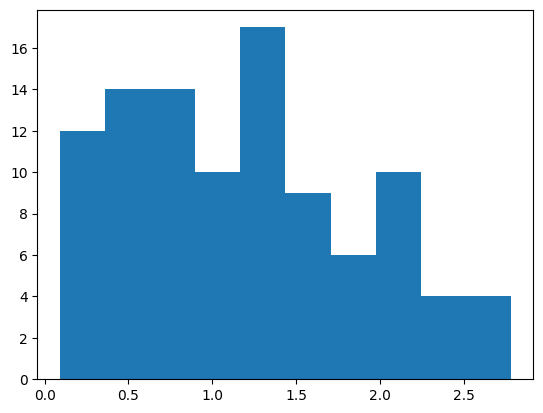

In [54]:
a_bunch = [rng.triangular(left=0, mode=0.7, right=3) for i in range(100)]
plt.hist(a_bunch)

In [62]:
from scipy.stats import truncnorm
a, b = (0 - 0.7) / 0.5, ( - 0.7) / 0.5  # standardized bounds
delta_mag = truncnorm.rvs(a, b, loc=0.7, scale=0.5, random_state=rng)

(array([19., 36., 41., 48., 19., 17., 14.,  3.,  2.,  1.]),
 array([0.01125793, 0.23436497, 0.45747201, 0.68057904, 0.90368608,
        1.12679312, 1.34990016, 1.57300719, 1.79611423, 2.01922127,
        2.24232831]),
 <BarContainer object of 10 artists>)

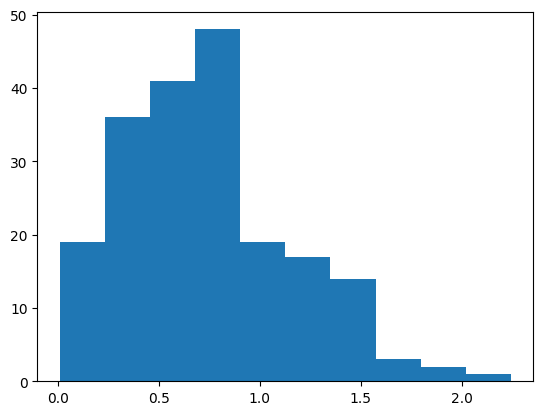

In [92]:
a, b = (0 - 0.7) / 0.5, (5 - 0.7) / 0.5  # standardized bounds

a_bunch = [truncnorm.rvs(a, b, loc=0.7, scale=0.5, random_state=rng) for i in range(200)]
plt.hist(a_bunch)

In [119]:
import pickle

In [137]:
lcdict = pickle.load(open(templates_file, "rb"))
lcdict["lightcurves"][0][f]['mag'][1]

np.float64(19.075793759734147)

In [141]:
def plot_template_lcs(templates_file, num=1, use_log_time=False, plot_overlap=False, ylim=None, plot_hours=True):
    '''
    Plot LC templates from a pickle. If plot_overlap=True, all requested templates
    are drawn on a single figure and the title lists every included template ID.
    ----------
    Parameters
    ----------
    templates_file : str
        Path to the pickle file containing LC templates.
    num : int
        Number of light curves to plot (from beginning of file).
    use_log_time : bool
        Whether to use log(time) on the x-axis.
    plot_overlap : bool
        If True, plot all LCs on one figure; otherwise, one plot per LC.
    ylim : tuple or None
        y-axis limits as (ymin, ymax). If None, don't set.
    '''

    lcdict = pickle.load(open(templates_file, "rb"))
    filters = ['u', 'g', 'r', 'i', 'z', 'y']
    colors = {'u': 'k', 'g': 'b', 'r': 'g', 'i': 'r', 'z': 'magenta', 'y': 'yellow'}

    n_avail = len(lcdict["lightcurves"])
    n_plot = min(num, n_avail)

    if plot_overlap:
        plt.figure()

    for i in range(n_plot):
        if not plot_overlap:
            plt.figure()

        for f in filters:
            time_vals = np.concatenate(([-.2,0],lcdict["lightcurves"][i][f]['ph'],[.2]))
            lc = np.concatenate(([lcdict["lightcurves"][i][f]['mag'][1],
                                 lcdict["lightcurves"][i][f]['mag'][1]], 
                                 lcdict["lightcurves"][i][f]['mag'],
                                [lcdict["lightcurves"][i][f]['mag'][1]]))
            if use_log_time and plot_hours:
                print("ERROR: can only use log time OR plot hours. using log time")
            if use_log_time:
                time_vals = np.log10(time_vals + 1e-5)
            if plot_hours:
                time_vals = time_vals*24

            plt.plot(
                time_vals,
                lc,
                color=colors[f],
                label=f if i == 0 else None,   # show filter legend once when overlapping
                alpha=0.5
            )

        # Titles & axes per-mode
        if not plot_overlap:
            plt.title(f"Light Curve Template #{i}", size=20)
            plt.xlabel("Log Time (days)" if use_log_time else "Time (days)", size=15)
            if plot_hours:
                plt.xlabel("Time (hours)", size=15)
            plt.ylabel("Absolute Mag", size=15)
            plt.gca().invert_yaxis()
            if ylim is not None:
                plt.ylim(ylim)
            plt.legend(prop={'size': 15})
            plt.tight_layout()
            plt.show()

    if plot_overlap:
        included_ids = ", ".join(f"#{k}" for k in range(n_plot))
        plt.title(f"Light Curve Templates {included_ids}", size=20)
        plt.xlabel("Log Time (days)" if use_log_time else "Time (days)", size=15)
        if plot_hours:
                plt.xlabel("Time (hours)", size=15)
        plt.ylabel("Absolute Mag", size=15)
        plt.gca().invert_yaxis()
        if ylim is not None:
            plt.ylim(ylim)
        plt.legend(prop={'size': 15})
        plt.tight_layout()
        plt.show()

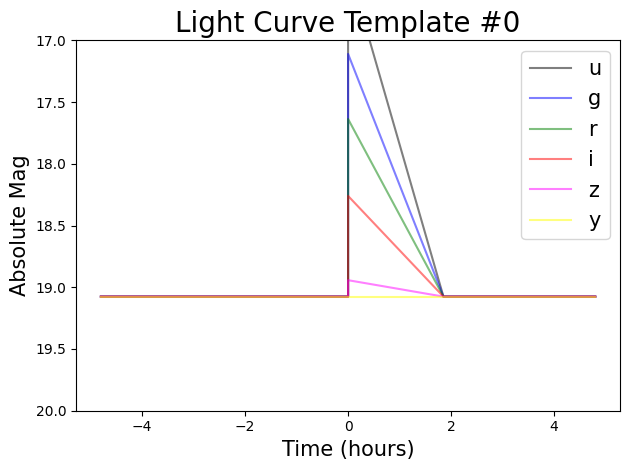

/tmp/ipykernel_3087/3326637651.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={'size': 15})


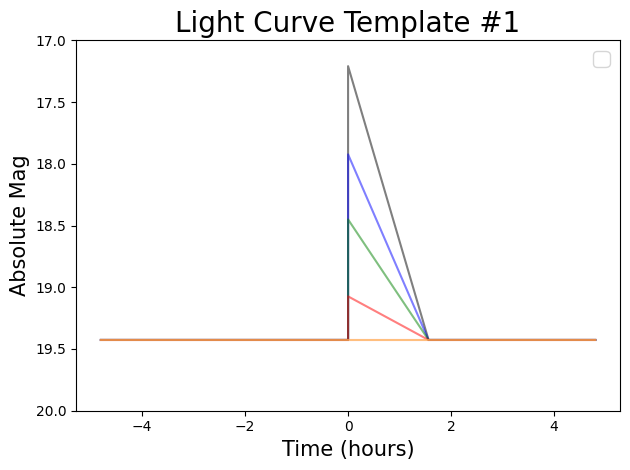

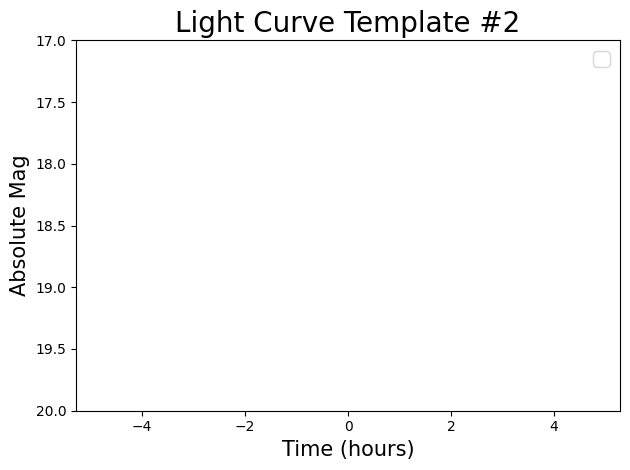

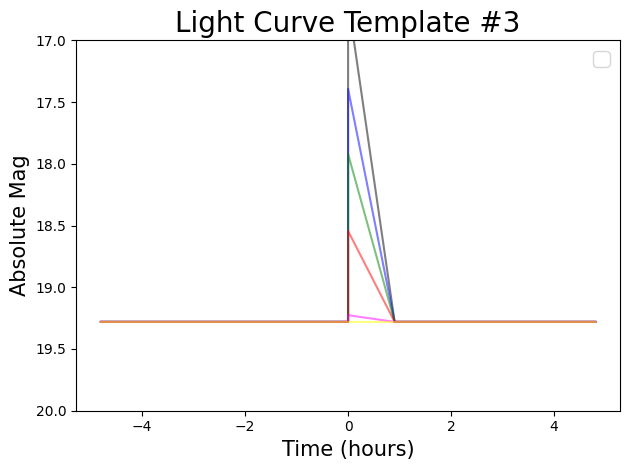

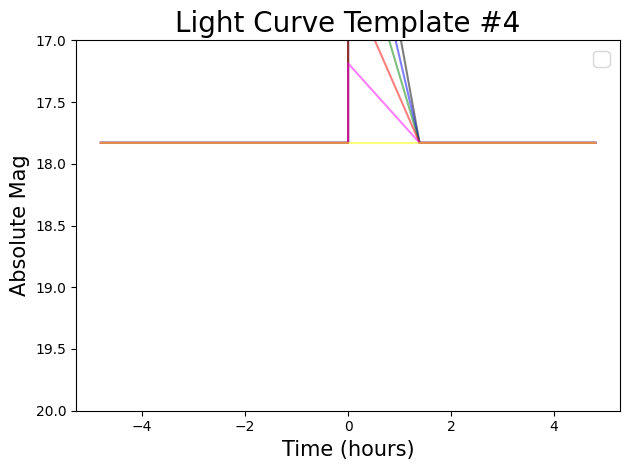

In [149]:
plot_template_lcs(templates_file, num=5,ylim=(20,17))

In [4]:
from scipy.stats import truncnorm

Text(0, 0.5, 'just to get a sense of scale, there are more than this')

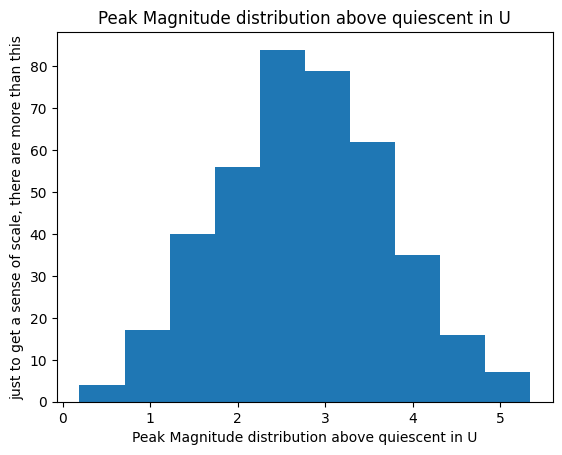

In [27]:
a, b = (0 - 2.7) / 1, (5.5 - 2.7) / 1  #  bounds for trunc no
delta_mags = []
for i in range(0,400):
    delta_mag = truncnorm.rvs(a, b, loc=2.7, scale=1)
    delta_mags.append(delta_mag)
plt.hist(delta_mags)
plt.title("Peak Magnitude distribution above quiescent in U")
plt.xlabel("Peak Magnitude distribution above quiescent in U")
plt.ylabel("just to get a sense of scale, there are more than this")